In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')








In [16]:



print("\n---: CREATING DATASET ---")

np.random.seed(42)
n = 500

study_hours     = np.random.uniform(1, 10, n)
attendance      = np.random.uniform(50, 100, n)
internal_score  = np.random.uniform(30, 100, n)
prev_result     = np.random.uniform(30, 100, n)
sleep_hours     = np.random.uniform(4, 10, n)
extra_activity  = np.random.randint(0, 4, n).astype(float)

final_score = (
    study_hours    * 3.0 +
    attendance     * 0.3 +
    internal_score * 0.4 +
    prev_result    * 0.2 +
    sleep_hours    * 1.0 +
    np.random.normal(0, 3, n)
)


---: CREATING DATASET ---


In [17]:
final_score = np.clip(final_score, 0, 100)


pass_fail = (final_score >= 62).astype(int)

df = pd.DataFrame({
    'study_hours'    : study_hours,
    'attendance'     : attendance,
    'internal_score' : internal_score,
    'prev_result'    : prev_result,
    'sleep_hours'    : sleep_hours,
    'extra_activity' : extra_activity,
    'final_score'    : final_score,
    'pass_fail'      : pass_fail
})


In [18]:

print("\nInjecting missing values into dataset...")
missing_rate = 0.10
cols_with_missing = ['study_hours', 'attendance', 'internal_score',
                     'prev_result', 'sleep_hours']

for col in cols_with_missing:
    missing_idx = np.random.choice(df.index, size=int(n * missing_rate),
                                   replace=False)
    df.loc[missing_idx, col] = np.nan

print(f"Missing values injected ({int(missing_rate*100)}% per column):")
print(df.isnull().sum())
print(f"Total missing cells : {df.isnull().sum().sum()}")

print(f"\nDataset created with {n} students and {df.shape[1]} columns.")
print(df.head(10).to_string())




Injecting missing values into dataset...
Missing values injected (10% per column):
study_hours       50
attendance        50
internal_score    50
prev_result       50
sleep_hours       50
extra_activity     0
final_score        0
pass_fail          0
dtype: int64
Total missing cells : 250

Dataset created with 500 students and 8 columns.
   study_hours  attendance  internal_score  prev_result  sleep_hours  extra_activity  final_score  pass_fail
0     4.370861         NaN       42.959305    66.335725     5.570234             2.0    79.347732          1
1     9.556429   76.804818       67.933066    63.542731     5.481873             2.0    94.029095          1
2     7.587945   65.476381       91.106209    31.794945     9.437527             2.0    92.213178          1
3     6.387926   90.689751       81.255742    53.887348     5.497277             2.0    91.375014          1
4     2.404168   84.236559             NaN          NaN          NaN             3.0    83.319560          1
5    

In [19]:


print("\n---: DATASET INFORMATION ---")

print("\nShape of dataset:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nBasic statistics:")
print(df.describe().round(2))
print("\nNumber of pass students:", (df['pass_fail'] == 1).sum())
print("Number of fail students:", (df['pass_fail'] == 0).sum())
print("Pass rate:", round((df['pass_fail'] == 1).mean() * 100, 2), "%")



---: DATASET INFORMATION ---

Shape of dataset: (500, 8)

Column names: ['study_hours', 'attendance', 'internal_score', 'prev_result', 'sleep_hours', 'extra_activity', 'final_score', 'pass_fail']

Data types:
study_hours       float64
attendance        float64
internal_score    float64
prev_result       float64
sleep_hours       float64
extra_activity    float64
final_score       float64
pass_fail           int64
dtype: object

First 5 rows:
   study_hours  attendance  internal_score  prev_result  sleep_hours  \
0     4.370861         NaN       42.959305    66.335725     5.570234   
1     9.556429   76.804818       67.933066    63.542731     5.481873   
2     7.587945   65.476381       91.106209    31.794945     9.437527   
3     6.387926   90.689751       81.255742    53.887348     5.497277   
4     2.404168   84.236559             NaN          NaN          NaN   

   extra_activity  final_score  pass_fail  
0             2.0    79.347732          1  
1             2.0    94.029095  

In [20]:


print("\n--- : MISSING VALUE CHECK & FILLING ---")

print("\nMissing values BEFORE filling:")
print(df.isnull().sum())
print(f"Total missing cells : {df.isnull().sum().sum()}")

# Show a few rows that have missing data
print("\nSample rows with missing values:")
print(df[df.isnull().any(axis=1)].head(8).to_string())


print("\nFilling strategy:")
print("  study_hours    → median")
print("  attendance     → mean")
print("  internal_score → median")
print("  prev_result    → mean")
print("  sleep_hours    → median")

df['study_hours']    = df['study_hours'].fillna(df['study_hours'].median())
df['attendance']     = df['attendance'].fillna(df['attendance'].mean())
df['internal_score'] = df['internal_score'].fillna(df['internal_score'].median())
df['prev_result']    = df['prev_result'].fillna(df['prev_result'].mean())
df['sleep_hours']    = df['sleep_hours'].fillna(df['sleep_hours'].median())

print("\nMissing values AFTER filling:")
print(df.isnull().sum())
print(f"Total missing cells : {df.isnull().sum().sum()}")
print(" All missing values successfully handled.")



--- : MISSING VALUE CHECK & FILLING ---

Missing values BEFORE filling:
study_hours       50
attendance        50
internal_score    50
prev_result       50
sleep_hours       50
extra_activity     0
final_score        0
pass_fail          0
dtype: int64
Total missing cells : 250

Sample rows with missing values:
    study_hours  attendance  internal_score  prev_result  sleep_hours  extra_activity  final_score  pass_fail
0      4.370861         NaN       42.959305    66.335725     5.570234             2.0    79.347732          1
4      2.404168   84.236559             NaN          NaN          NaN             3.0    83.319560          1
10     1.185260   80.670760       45.484661          NaN     4.201682             0.0    65.028927          1
11     9.729189   70.912152       99.136761          NaN     4.375919             3.0   100.000000          1
14     2.636425         NaN       79.390262    43.704459     7.194524             0.0    77.349894          1
20     6.506676   79.70653

In [21]:


print("\n---  DUPLICATE CHECK ---")

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found. Dataset is clean.")

print(f"Dataset shape after duplicate check: {df.shape}")


---  DUPLICATE CHECK ---
Number of duplicate rows: 0
No duplicates found. Dataset is clean.
Dataset shape after duplicate check: (500, 8)


In [22]:


print("\n--- : OUTLIER DETECTION ---")

feature_cols = ['study_hours', 'attendance', 'internal_score',
                'prev_result', 'sleep_hours', 'extra_activity']

for col in feature_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers (lower={lower:.2f}, upper={upper:.2f})")


--- : OUTLIER DETECTION ---
  study_hours: 0 outliers (lower=-2.76, upper=13.89)
  attendance: 0 outliers (lower=30.40, upper=115.75)
  internal_score: 0 outliers (lower=-1.78, upper=132.27)
  prev_result: 0 outliers (lower=2.77, upper=126.60)
  sleep_hours: 0 outliers (lower=2.09, upper=11.97)
  extra_activity: 0 outliers (lower=-4.50, upper=7.50)


In [23]:



print("\n--- : NORMALIZATION (StandardScaler) ---")

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Before normalization (study_hours):", df['study_hours'].values[:5].round(2))
print("After  normalization (study_hours):", df_scaled['study_hours'].values[:5].round(2))
print("\nNormalized feature means (should be ~0):")
print(df_scaled[feature_cols].mean().round(4))
print("Normalized feature stds (should be ~1):")
print(df_scaled[feature_cols].std().round(4))



--- : NORMALIZATION (StandardScaler) ---
Before normalization (study_hours): [4.37 9.56 7.59 6.39 2.4 ]
After  normalization (study_hours): [-0.45  1.56  0.8   0.33 -1.21]

Normalized feature means (should be ~0):
study_hours      -0.0
attendance       -0.0
internal_score   -0.0
prev_result      -0.0
sleep_hours       0.0
extra_activity    0.0
dtype: float64
Normalized feature stds (should be ~1):
study_hours       1.001
attendance        1.001
internal_score    1.001
prev_result       1.001
sleep_hours       1.001
extra_activity    1.001
dtype: float64



---EDA - HISTOGRAMS ---


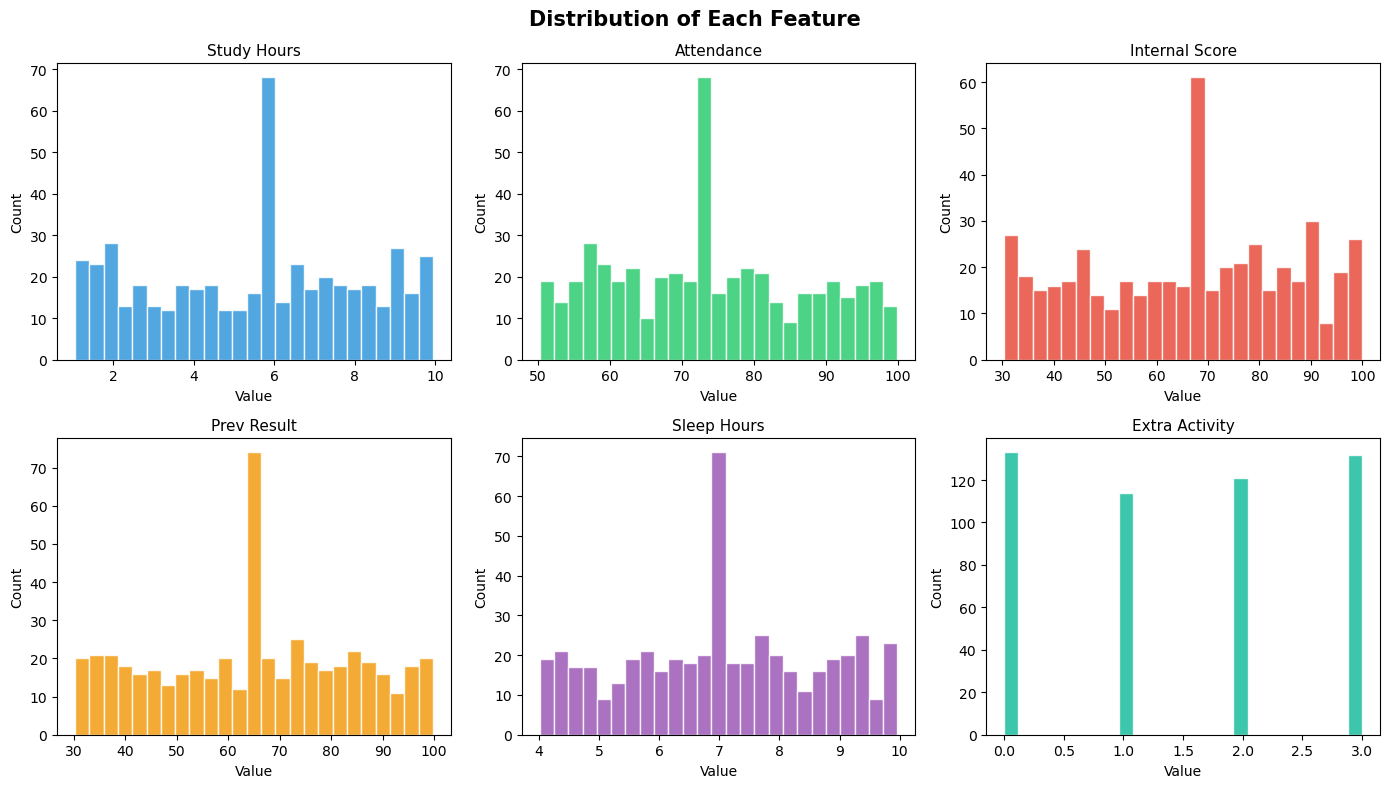

Histogram plot saved as histograms.png


In [24]:

print("\n---EDA - HISTOGRAMS ---")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribution of Each Feature", fontsize=15, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram plot saved as histograms.png")




--- : EDA - BOX PLOTS ---


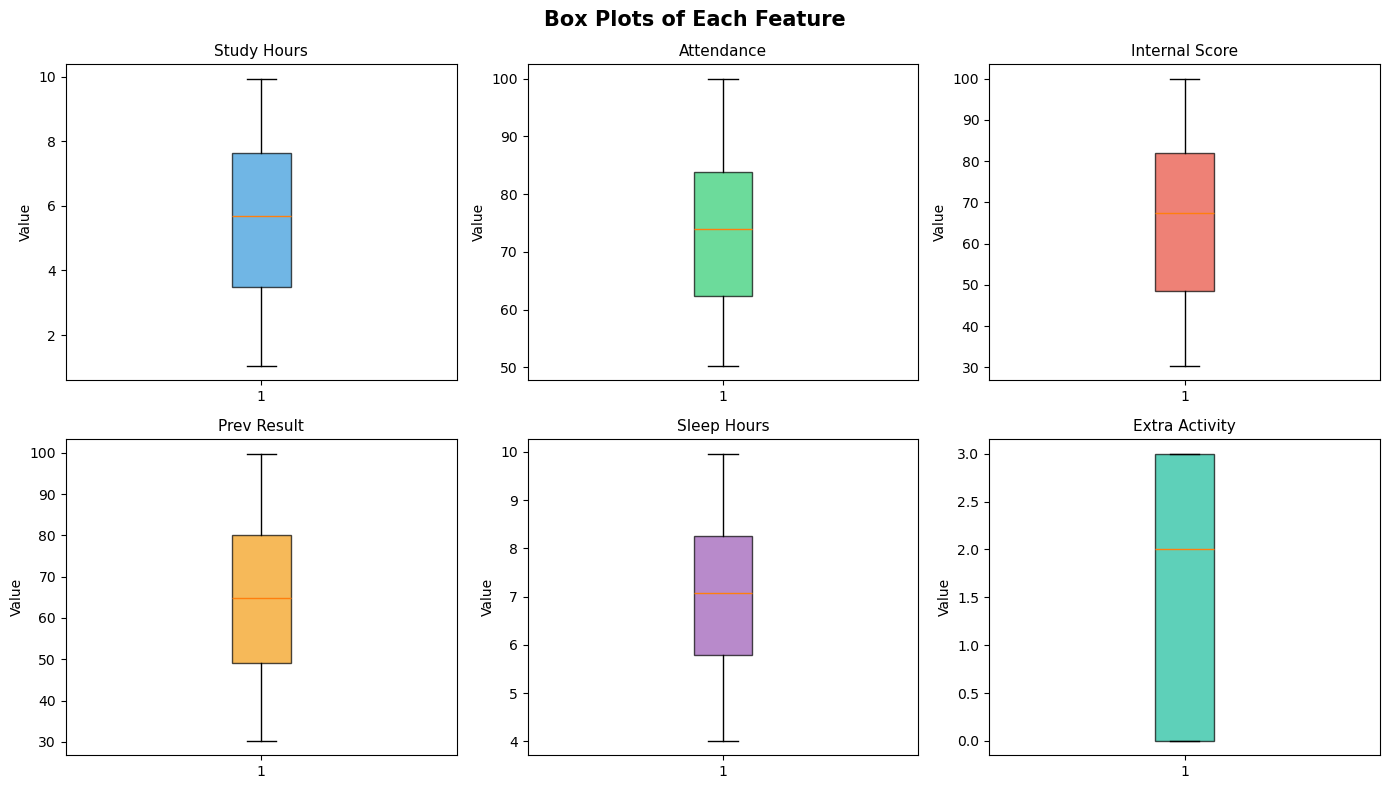

Box plot saved as boxplots.png


In [25]:



print("\n--- : EDA - BOX PLOTS ---")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Box Plots of Each Feature", fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot saved as boxplots.png")


--- - SCATTER PLOTS vs FINAL SCORE ---


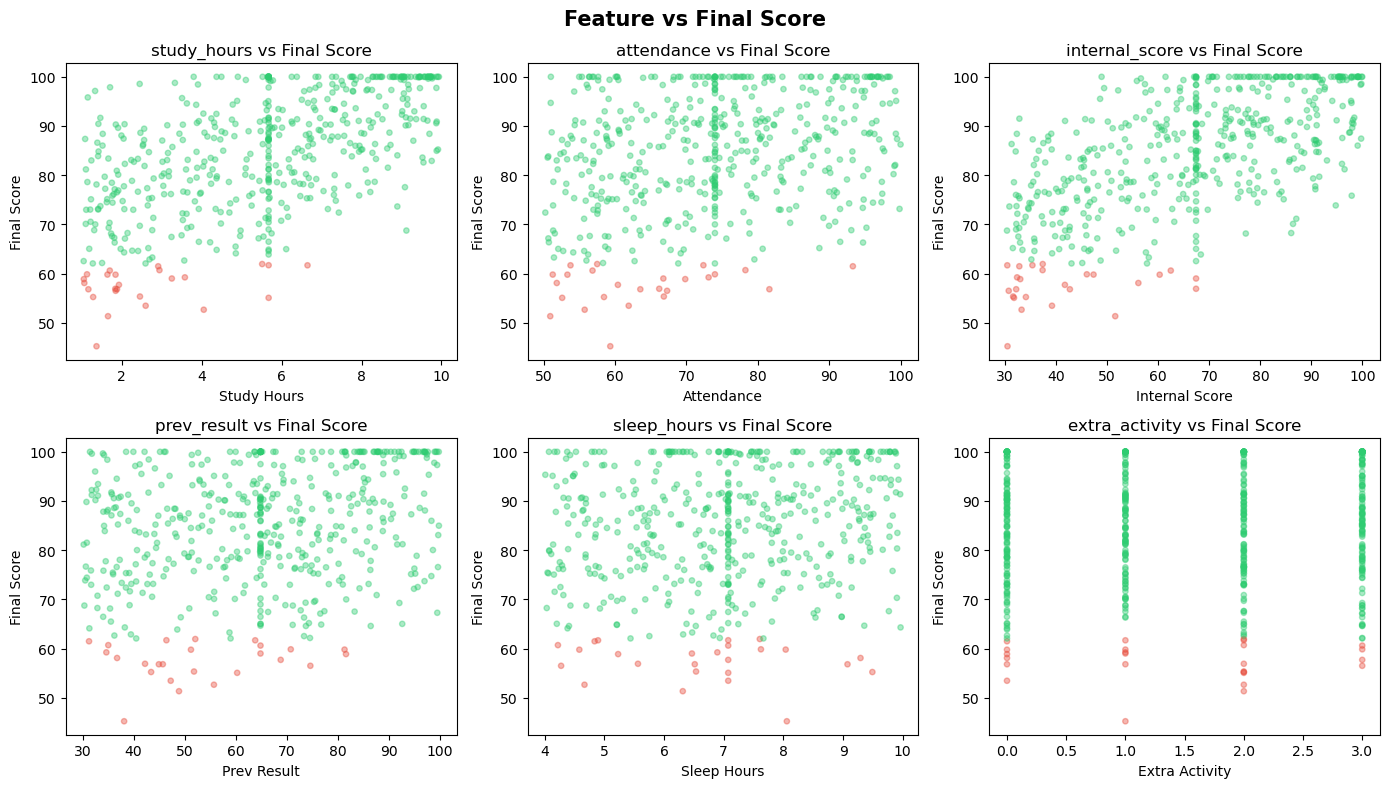

Scatter plots saved as scatter_plots.png
(Green dots = Pass, Red dots = Fail)


In [26]:

print("\n--- - SCATTER PLOTS vs FINAL SCORE ---")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Feature vs Final Score", fontsize=15, fontweight='bold')
axes = axes.flatten()

dot_colors = ['#e74c3c' if p == 0 else '#2ecc71' for p in df['pass_fail']]

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df['final_score'],
                    c=dot_colors, alpha=0.4, s=15)
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel('Final Score')
    axes[i].set_title(f'{col} vs Final Score')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plots saved as scatter_plots.png")
print("(Green dots = Pass, Red dots = Fail)")



--- CORRELATION ANALYSIS ---

Correlation with final_score:
internal_score    0.618
study_hours       0.583
pass_fail         0.507
attendance        0.292
prev_result       0.244
sleep_hours       0.162
extra_activity    0.050
Name: final_score, dtype: float64

Correlation with pass_fail:
final_score       0.507
internal_score    0.281
study_hours       0.255
attendance        0.171
prev_result       0.137
sleep_hours       0.059
extra_activity    0.013
Name: pass_fail, dtype: float64


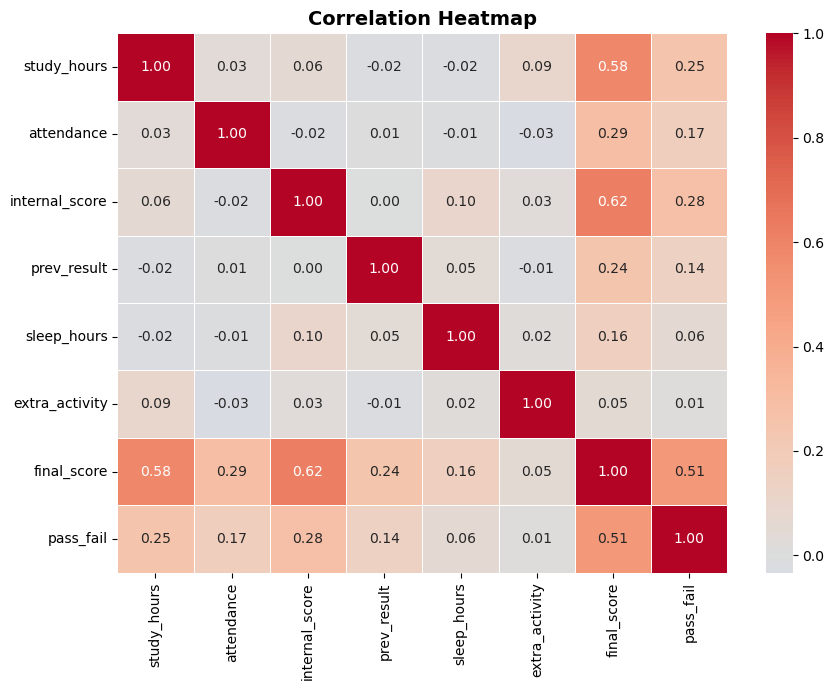

Correlation heatmap saved as correlation_heatmap.png


In [27]:



print("\n--- CORRELATION ANALYSIS ---")

corr_matrix = df[feature_cols + ['final_score', 'pass_fail']].corr()

print("\nCorrelation with final_score:")
corr_with_target = corr_matrix['final_score'].drop('final_score').sort_values(ascending=False)
print(corr_with_target.round(3))

print("\nCorrelation with pass_fail:")
corr_with_pf = corr_matrix['pass_fail'].drop('pass_fail').sort_values(ascending=False)
print(corr_with_pf.round(3))


fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved as correlation_heatmap.png")